# `processing-dataset.ipynb`


goal is to first take out properties from a single labelled file, and then scale it up across mutliple such directories. the model won't see test data!

imports

In [1]:
import xml.etree.ElementTree as ET
import sqlite3
import os
import matplotlib.pyplot as plt
import sqlite3

In [8]:
!cd ../dataset/TrainINKML_2013 && type 101_fujita.inkml # prints the file

<ink xmlns="http://www.w3.org/2003/InkML">
<traceFormat>
<channel name="X" type="decimal"/>
<channel name="Y" type="decimal"/>
</traceFormat>
<annotation type="category">Arithmetic</annotation>
<annotation type="expression">101</annotation>
 <annotation type="UI">101_fujita</annotation>
<annotation type="writer">fujita</annotation>
<annotation type="truth">$S = \Bigg( \sum_{i=1}^{n} \theta_i - (n-2)\pi \Bigg)r^2$</annotation>
<annotationXML type="truth" encoding="Content-MathML">
	<math xmlns='http://www.w3.org/1998/Math/MathML'>
		<mrow>
			<mi xml:id="S_1">S</mi>
			<mrow>
				<mo xml:id="=_1">=</mo>
				<mrow>
					<mo xml:id="(_1">(</mo>
					<mrow>
						<msubsup>
							<mo xml:id="sum_1">\sum</mo>
							<mrow>
								<mi xml:id="i_1">i</mi>
								<mrow>
									<mo xml:id="=_2">=</mo>
									<mn xml:id="1_1">1</mn>
								</mrow>
							</mrow>
							<mi xml:id="n_1">n</mi>
						</msubsup>
						<mrow>
							<msub>
								<mi xml:id="theta_1">\theta</mi>
								<mi 


101_fujita.inkml


The system cannot find the file specified.
Error occurred while processing: #.
The system cannot find the file specified.
Error occurred while processing: prints.
The system cannot find the file specified.
Error occurred while processing: the.
The system cannot find the file specified.
Error occurred while processing: file.


In [2]:
def inkplot_with_boxes(filename=None, directory="TrainINKML_2013", filepath=None):
    ns = "{http://www.w3.org/2003/InkML}"
    tree = ET.parse(
        f"../dataset/{directory}/{filename}"
    ) if (filename and directory and not filepath) else ET.parse(filepath)

    root = tree.getroot()

    # collect all traces by id
    traces = {}
    for trace in root.iter(f"{ns}trace"):
        tid = trace.attrib["id"]
        raw = trace.text.strip()
        pts = [tuple(map(float, p.split())) for p in raw.split(",")]
        traces[tid] = pts

    # collect symbols (TraceGroups)
    symbols = []
    for tg in root.iter(f"{ns}TraceGroup"):
        # label
        ann = tg.find(f"{ns}annotation")
        if ann is None:
            continue
        label = ann.text.strip()

        # strokes in this symbol
        stroke_ids = [
            tv.attrib["traceDataRef"]
            for tv in tg.findall(f"{ns}traceView")
        ]

        # merge all points
        pts = []
        for sid in stroke_ids:
            pts.extend(traces[sid])

        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]
        xmin, xmax = min(xs), max(xs)
        ymin, ymax = min(ys), max(ys)

        symbols.append({
            "label": label,
            "bbox": (xmin, ymin, xmax, ymax),
            "stroke_ids": stroke_ids
        })

    # plot
    plt.figure(figsize=(5,5))

    # strokes
    for pts in traces.values():
        xs, ys = zip(*pts)
        plt.plot(xs, ys, linewidth=1, color="black")

    # boxes + labels
    for s in symbols:
        xmin, ymin, xmax, ymax = s["bbox"]
        plt.plot([xmin, xmax, xmax, xmin, xmin],
                 [ymin, ymin, ymax, ymax, ymin],
                 color="red")

        cx = (xmin + xmax) / 2
        cy = (ymin + ymax) / 2
        plt.text(cx, cy, s["label"],
                 ha='center', va='center',
                 fontsize=10, color="blue")

    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.show()

we're targetting a specific file as of now, it exists at: `TrainINKML_2013/101_fujita.inkml`

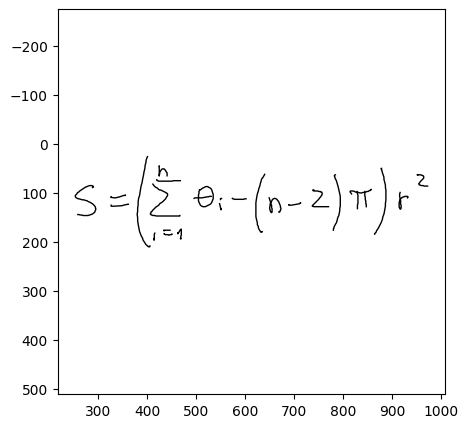

In [3]:
inkplot_with_boxes(filename="101_fujita.inkml", directory="TrainINKML_2013")

this is a good expression to get started with, because it's got multiple unique symbols and is quite clear in what it says

now a function that parses **truth**

In [16]:
NS = {"ink": "http://www.w3.org/2003/InkML"}

def parse_inkml(filename=None, directory=None, inkml_path=None):
    # Resolve path
    if inkml_path:
        path = inkml_path
    else:
        path = f"../dataset/{directory}/{filename}"

    tree = ET.parse(path)
    root = tree.getroot()

    # Truth
    ann = root.find(".//ink:annotation[@type='truth']", NS)
    truth_raw = ann.text.strip() if ann is not None else None
    truth = truth_raw
    if truth_raw:
        if truth.startswith("$"):
            truth = truth[1:].lstrip()
        if truth.endswith("$"):
            truth = truth[:-1].rstrip()

    # Traces and boxes
    traces = []
    bboxes = []
    for trace in root.findall(".//ink:trace", NS):
        pts = []
        for p in trace.text.strip().split(","):
            xy = p.strip().split()
            if len(xy) == 2:
                x, y = map(float, xy)
                pts.append((x, y))
        if pts:
            traces.append(pts)
            xs = [p[0] for p in pts]
            ys = [p[1] for p in pts]
            bboxes.append((min(xs), min(ys), max(xs), max(ys)))

    return {
        "path": path,
        "truth_raw": truth_raw,
        "truth": truth,
        "traces": traces,
        "bboxes": bboxes,
    }
def clean_truth(raw):
    if raw is None:
        return None
    s = raw.strip()

    # If starts with $, drop only the first
    if s.startswith("$"):
        s = s[1:].lstrip()

    # If ends with $, drop only the last
    if s.endswith("$"):
        s = s[:-1].rstrip()

    return s

def parse_inkml_symbols(filename= None, directory=None, inkml_path=None):
    if inkml_path:
        path = inkml_path
    else:
        path = f"../dataset/{directory}/{filename}"
    tree = ET.parse(path)
    root = tree.getroot()

    # map trace id → points
    trace_map = {}
    for tr in root.findall(".//ink:trace", NS):
        tid = tr.get("id")
        pts = []
        for p in tr.text.strip().split(","):
            xy = p.strip().split()
            if len(xy) == 2:
                pts.append((float(xy[0]), float(xy[1])))
        if pts:
            trace_map[tid] = pts

    symbols = []
    for tg in root.findall(".//ink:traceGroup", NS):
        views = tg.findall("ink:traceView", NS)
        if not views:
            continue

        ann = tg.find("ink:annotation[@type='truth']", NS)
        label = ann.text.strip() if ann is not None else None

        group_traces = []
        for v in views:
            ref = v.get("traceDataRef")
            if ref in trace_map:
                group_traces.append(trace_map[ref])

        if label and group_traces:
            symbols.append({
                "label": label,
                "traces": group_traces,
                "path": path
            })

    return symbols

In [25]:
truth = parse_inkml(filename="101_fujita.inkml", directory="TrainINKML_2013")
truth['truth']

'S = \\Bigg( \\sum_{i=1}^{n} \\theta_i - (n-2)\\pi \\Bigg)r^2'

here we got the (symbols) truth

In [26]:
truth['traces'][:1]

[[(289.0, 89.0)]]

and there we're getting the traces! now the next step is to use this function across all files of our folder. this is an extensive job and we need to make sure we do a few things right before diving right in:

so let's hear a few points out loud-

* handle errors, skip the files that aren't labelled, many directories in our dataset contains some problematic files, or files with on labelling. skip those, don't entertain.
* query local database and look for duplicate entries once it's done
* a file's database `id` will be assigned on write, it will be an auto-incrementing integer which will contain both the bounding box data (and truth data in case we need it) and file's name as well as its directory so we can avoid cases where two duplicates exists in different directories.
* a group of traces might represent a single symbol, writing this just for the record (inkml do handle all those blahs)

but first, let's write a bounding a box algorithm and see if it works on this fujita file!

#### synthesizing a bounding box algorithm to train our YOLO model

stuff we'd care about while finding the best fit box: width, height, center coords! these are all that a YOLO model typically needs so we're gonna give it those. let's test it out then.

we'll be using `sqlite3` for the database

In [5]:
import sqlite3
from typing import Optional

class InkMLDatabase:
    def __init__(self, db_path: str = "inkml_data.db"):
        self.db_path = db_path
        self._init_db()

    def _connect(self):
        return sqlite3.connect(self.db_path)

    def _init_db(self):
        conn = self._connect()
        cur = conn.cursor()
        cur.execute("""
        CREATE TABLE IF NOT EXISTS samples (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            file_path TEXT NOT NULL,
            symbol_label TEXT,
            xmin REAL,
            ymin REAL,
            xmax REAL,
            ymax REAL
        );
        """)
        conn.commit()
        conn.close()

    def add_sample(self,
                   file_path: str,
                   symbol_label: Optional[str],
                   xmin: float,
                   ymin: float,
                   xmax: float,
                   ymax: float) -> int:
        conn = self._connect()
        cur = conn.cursor()
        cur.execute(
            "INSERT INTO samples (file_path, symbol_label, xmin, ymin, xmax, ymax) VALUES (?, ?, ?, ?, ?, ?)",
            (file_path, symbol_label, xmin, ymin, xmax, ymax)
        )
        sid = cur.lastrowid
        conn.commit()
        conn.close()
        return sid

    def get_sample(self, sample_id: int):
        conn = self._connect()
        cur = conn.cursor()
        cur.execute("SELECT * FROM samples WHERE id=?", (sample_id,))
        row = cur.fetchone()
        conn.close()
        return row

    def get_all_samples(self):
        conn = self._connect()
        cur = conn.cursor()
        cur.execute("SELECT * FROM samples")
        rows = cur.fetchall()
        conn.close()
        return rows

In [17]:
def boxn(filename= None, directory= None):
    if not filename or not directory:
        return
    symbols = parse_inkml_symbols(filename, directory)
    if not symbols:
        return []
    results = []

    for s in symbols:
        xs = []
        ys = []
        for trace in s["traces"]:
            for x, y in trace:
                xs.append(x)
                ys.append(y)
        xmin = min(xs)
        ymin = min(ys)
        xmax = max(xs)
        ymax = max(ys)

        results.append({
            "label" : s["label"],
            "bbox" : (xmin, ymin, xmax, ymax),
            "path": s["path"]
        })
    return results
els = boxn(filename="101_fujita.inkml", directory="TrainINKML_2013")
els

[{'label': 'S',
  'bbox': (254.0, 85.0, 296.0, 146.0),
  'path': '../dataset/TrainINKML_2013/101_fujita.inkml'},
 {'label': '=',
  'bbox': (326.0, 104.0, 362.0, 127.0),
  'path': '../dataset/TrainINKML_2013/101_fujita.inkml'},
 {'label': '(',
  'bbox': (380.0, 26.0, 406.0, 210.0),
  'path': '../dataset/TrainINKML_2013/101_fujita.inkml'},
 {'label': '\\sum',
  'bbox': (407.0, 73.0, 468.0, 147.0),
  'path': '../dataset/TrainINKML_2013/101_fujita.inkml'},
 {'label': 'i',
  'bbox': (414.0, 167.0, 419.0, 196.0),
  'path': '../dataset/TrainINKML_2013/101_fujita.inkml'},
 {'label': '=',
  'bbox': (434.0, 176.0, 451.0, 186.0),
  'path': '../dataset/TrainINKML_2013/101_fujita.inkml'},
 {'label': '1',
  'bbox': (463.0, 174.0, 470.0, 194.0),
  'path': '../dataset/TrainINKML_2013/101_fujita.inkml'},
 {'label': 'n',
  'bbox': (424.0, 45.0, 441.0, 65.0),
  'path': '../dataset/TrainINKML_2013/101_fujita.inkml'},
 {'label': '\\theta',
  'bbox': (496.0, 87.0, 535.0, 128.0),
  'path': '../dataset/TrainI

**<span style="color:green">It works!</span>**

#### inserting symbols rows
putting all this data in a relational database will easen the training process for us significantly.

first directory we're gonna be targetting: `TrainINKML_2013`

> quick heads up

In [18]:
!cd ../dataset && dir

 Volume in drive C has no label.
 Volume Serial Number is 5EAB-43CF

 Directory of C:\Users\welcome\Development\Jupyter\math-cnn\dataset

24-11-2025  21:52    <DIR>          .
26-11-2025  19:25    <DIR>          ..
24-11-2025  21:48    <DIR>          CROHME_test_2011
24-11-2025  21:48    <DIR>          CROHME_training_2011
24-11-2025  21:48    <DIR>          MatricesTest2014
24-11-2025  21:48    <DIR>          MatricesTrain2014
24-11-2025  21:52    <DIR>          testData_2012
24-11-2025  21:48    <DIR>          TestINKML_2013
24-11-2025  21:52    <DIR>          trainData_2012_part1
24-11-2025  21:52    <DIR>          trainData_2012_part2
24-11-2025  21:50    <DIR>          TrainINKML_2013
               0 File(s)              0 bytes
              11 Dir(s)  224,010,022,912 bytes free


In [50]:
import os
import glob

target_folder = "trainData_2012_part2"
folder = f"../dataset/{target_folder}"
db_class = InkMLDatabase()

for file_path in glob.glob(os.path.join(folder, "*.inkml")):
    filename = os.path.basename(file_path)

    try:
        rows = boxn(filename=filename, directory=target_folder)
    except Exception as e:
        print("skip:", filename, e)
        continue

    if not rows:
        continue

    for r in rows:
        db_class.add_sample(
            r["path"],
            r["label"],
            r["bbox"][0],
            r["bbox"][1],
            r["bbox"][2],
            r["bbox"][3]
        )

In [51]:
import sqlite3

conn = sqlite3.connect("inkml_data.db")
cur = conn.cursor()

cur.execute("SELECT COUNT(*) FROM samples")
print(cur.fetchone()[0])
conn.close()

100949


In [25]:
!dir

 Volume in drive C has no label.
 Volume Serial Number is 5EAB-43CF

 Directory of C:\Users\welcome\Development\Jupyter\math-cnn\math-cnn

28-11-2025  14:48    <DIR>          .
26-11-2025  19:25    <DIR>          ..
26-11-2025  19:33    <DIR>          .ipynb_checkpoints
28-11-2025  14:48                 0 inkml.db
28-11-2025  14:45         5,017,600 inkml_data.db
28-11-2025  14:47            69,628 processing-dataset.ipynb
28-11-2025  14:48                 0 symbols.db
               4 File(s)      5,087,228 bytes
               3 Dir(s)  223,928,270,848 bytes free


checking for duplicate vals and acting on them

In [56]:
import sqlite3

conn = sqlite3.connect("inkml_data.db")
cur = conn.cursor()

cur.execute("""
SELECT COUNT(*) - COUNT(DISTINCT file_path || symbol_label || xmin || ymin || xmax || ymax)
FROM samples
""")
dup_count = cur.fetchone()[0]
print(dup_count)

conn.close()

0


there are 57191 duplicates in total (ig from the first run)

this next cell removes them:

In [55]:
import sqlite3

conn = sqlite3.connect("inkml_data.db")
cur = conn.cursor()

cur.execute("""
DELETE FROM samples
WHERE rowid NOT IN (
    SELECT MIN(rowid)
    FROM samples
    GROUP BY file_path, symbol_label, xmin, ymin, xmax, ymax
)
""")

conn.commit()
conn.close()

In [45]:
import sqlite3

conn = sqlite3.connect("inkml_data.db")
cur = conn.cursor()

cur.execute("SELECT * FROM samples LIMIT 10")
for row in cur.fetchall():
    print(row)

conn.close()

(1, '../dataset/TrainINKML_2013/101_alfonso.inkml', 'S', 322.0, 105.0, 371.0, 159.0)
(2, '../dataset/TrainINKML_2013/101_alfonso.inkml', '=', 392.0, 131.0, 426.0, 147.0)
(3, '../dataset/TrainINKML_2013/101_alfonso.inkml', '(', 462.0, 61.0, 485.0, 193.0)
(4, '../dataset/TrainINKML_2013/101_alfonso.inkml', '\\sum', 502.0, 103.0, 575.0, 146.0)
(5, '../dataset/TrainINKML_2013/101_alfonso.inkml', 'i', 501.0, 165.0, 523.0, 191.0)
(6, '../dataset/TrainINKML_2013/101_alfonso.inkml', '=', 533.0, 178.0, 553.0, 189.0)
(7, '../dataset/TrainINKML_2013/101_alfonso.inkml', '1', 566.0, 169.0, 590.0, 192.0)
(8, '../dataset/TrainINKML_2013/101_alfonso.inkml', 'n', 523.0, 71.0, 543.0, 92.0)
(9, '../dataset/TrainINKML_2013/101_alfonso.inkml', '\\theta', 603.0, 101.0, 633.0, 140.0)
(10, '../dataset/TrainINKML_2013/101_alfonso.inkml', 'i', 632.0, 137.0, 655.0, 162.0)


#### printing out unique symbols we gathered
this is ran after sampling these folders: `MatricesTest2014`, `TrainINKML_2013`, `CROHME_training_2011`

In [53]:
import sqlite3

conn = sqlite3.connect("inkml_data.db")
cur = conn.cursor()

cur.execute("SELECT DISTINCT symbol_label FROM samples ORDER BY symbol_label")
symbols = [r[0] for r in cur.fetchall()]

conn.close()
print(symbols)

['!', '(', ')', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '=', 'A', 'B', 'C', 'E', 'F', 'G', 'H', 'I', 'L', 'M', 'N', 'P', 'R', 'S', 'T', 'V', 'X', 'Y', '[', '\\Delta', '\\alpha', '\\beta', '\\cos', '\\div', '\\exists', '\\forall', '\\gamma', '\\geq', '\\gt', '\\in', '\\infty', '\\int', '\\lambda', '\\ldots', '\\leq', '\\lim', '\\log', '\\lt', '\\mu', '\\neq', '\\phi', '\\pi', '\\pm', '\\prime', '\\rightarrow', '\\sigma', '\\sin', '\\sqrt', '\\sum', '\\tan', '\\theta', '\\times', '\\{', '\\}', ']', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '|']


that's it, the data's prepared!